In [2]:
#Task 6: Customer Segmentation
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
df = pd.read_csv(r"C:\Users\DELL\Desktop\Mall_Customers.csv")
print("Dataset Preview")
print(df.head())

Dataset Preview
   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [3]:
# TASK 1 : DATA PREPROCESSING
print("\nMissing Values:")
print(df.isnull().sum())
df = df.drop_duplicates()
print("\nDataset Shape After Removing Duplicates:")
print(df.shape)


Missing Values:
CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Dataset Shape After Removing Duplicates:
(200, 5)


In [4]:
# TASK 2 : APPLY K-MEANS CLUSTERING
X = df[["Annual Income (k$)", "Spending Score (1-100)"]]
kmeans = KMeans(n_clusters=5, random_state=42)
df["Cluster"] = kmeans.fit_predict(X)
print("\nCustomer Clusters:")
print(df[["CustomerID", "Cluster"]].head())


Customer Clusters:
   CustomerID  Cluster
0           1        4
1           2        2
2           3        4
3           4        2
4           5        4


C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


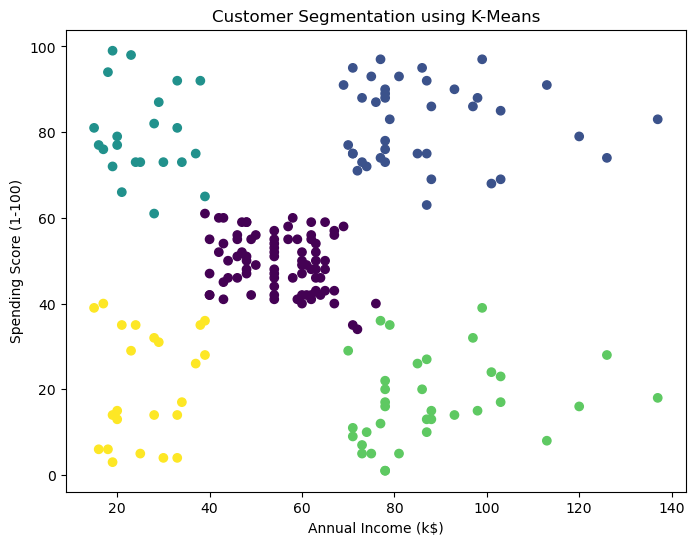

In [5]:
# TASK 3 : VISUALIZE CLUSTERS
plt.figure(figsize=(8,6))
plt.scatter(
    X["Annual Income (k$)"],
    X["Spending Score (1-100)"],
    c=df["Cluster"]
)
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Segmentation using K-Means")
plt.show()

In [6]:
# CUSTOMER SEGMENT INSIGHTS
print("\nCluster Summary")
print(
    df.groupby("Cluster")
    [["Annual Income (k$)", "Spending Score (1-100)"]]
    .mean()
)


Cluster Summary
         Annual Income (k$)  Spending Score (1-100)
Cluster                                            
0                 55.296296               49.518519
1                 86.538462               82.128205
2                 25.727273               79.363636
3                 88.200000               17.114286
4                 26.304348               20.913043
